# Notebook 1 - Toy problems in NumPy with simple gradient descent

This notebook is a playground for reviewing the basics of gradient-based optimization in machine learning.

## Goals
By the end of this notebook, we should be able to:
- understand what an objective (loss) function is
- compute gradients for simple models
- implement vanilla gradient descent in NumPy
- visualize convergence on toy problems
- train a tiny linear regression model
- train a tiny logistic regression classifier

The emphasis here is **clarity**, not performance.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 2. Warm-up: one-dimensional optimization

We start with a simple scalar function:

$$f(x) = (x-3)^2 + 1$$

Its gradient is


$$f'(x) = 2(x-3)$$

Gradient descent updates

$$x_{t+1} = x_t - \eta f'(x_t), $$
where $\eta$ is the learning rate. 
For this example we let $\eta$ to be a constant.

In [2]:
def f1(x):
    return (x - 3.0)**2 + 1.0

def grad_f1(x):
    return 2.0 * (x - 3.0)

def gradient_descent_1d(x0, lr=0.1, steps=20):
    x = float(x0)
    xs = [x]
    fs = [f1(x)]
    for _ in range(steps):
        x = x - lr * grad_f1(x)
        xs.append(x)
        fs.append(f1(x))
    return np.array(xs), np.array(fs)

xs, fs = gradient_descent_1d(x0=-4.0, lr=0.2, steps=20)
xs[:5], fs[:5]

(array([-4.    , -1.2   ,  0.48  ,  1.488 ,  2.0928]),
 array([50.        , 18.64      ,  7.3504    ,  3.286144  ,  1.82301184]))

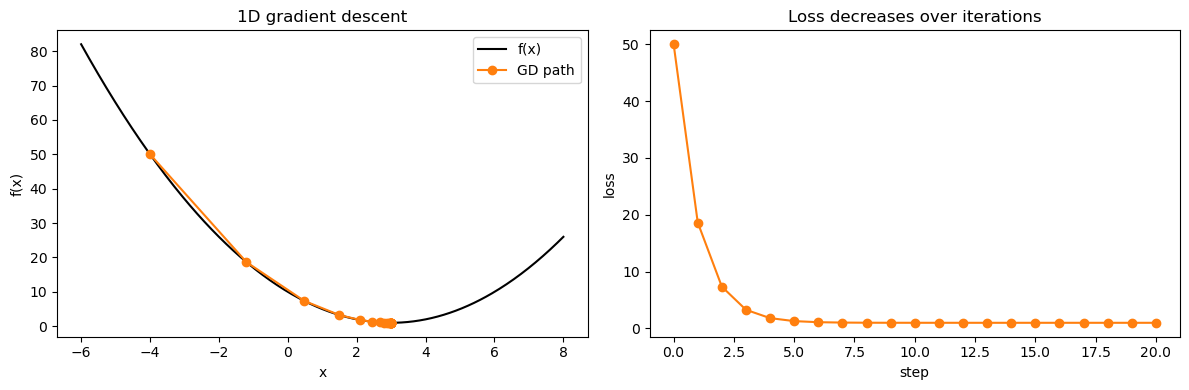

In [8]:
x_grid = np.linspace(-6, 8, 400)
y_grid = f1(x_grid)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(x_grid, y_grid, label='f(x)',c='k')
axs[0].plot(xs, fs, 'o-', label='GD path',c='C1')
axs[0].set_xlabel('x')
axs[0].set_ylabel('f(x)')
axs[0].set_title('1D gradient descent')
axs[0].legend()

axs[1].plot(fs, marker='o',c='C1')
axs[1].set_xlabel('step')
axs[1].set_ylabel('loss')
axs[1].set_title('Loss decreases over iterations')

plt.tight_layout()
plt.show()

## 3. Two-dimensional quadratic bowl

Now consider a 2D quadratic:

$$f(\mathbf{w}) = \frac12 \mathbf{w}^T A \mathbf{w}$$

with gradient

$$\nabla f(\mathbf{w}) = A\mathbf{w}.$$

This is useful because it shows how gradient descent behaves on anisotropic surface.

In [9]:
A = np.array([[1.0, 0.0],
              [0.0, 10.0]])

def quad_loss(w, A=A):
    return 0.5 * w @ A @ w

def quad_grad(w, A=A):
    return A @ w

def gradient_descent(w0, grad_fn, loss_fn, lr=0.1, steps=50):
    w = np.array(w0, dtype=float)
    ws = [w.copy()]
    losses = [loss_fn(w)]
    for _ in range(steps):
        g = grad_fn(w)
        w = w - lr * g
        ws.append(w.copy())
        losses.append(loss_fn(w))
    return np.array(ws), np.array(losses)

w0 = np.array([5.0, 5.0])
ws, losses = gradient_descent(w0, quad_grad, quad_loss, lr=0.12, steps=30)
ws[:3], losses[:3]

(array([[ 5.   ,  5.   ],
        [ 4.4  , -1.   ],
        [ 3.872,  0.2  ]]),
 array([137.5     ,  14.68    ,   7.696192]))

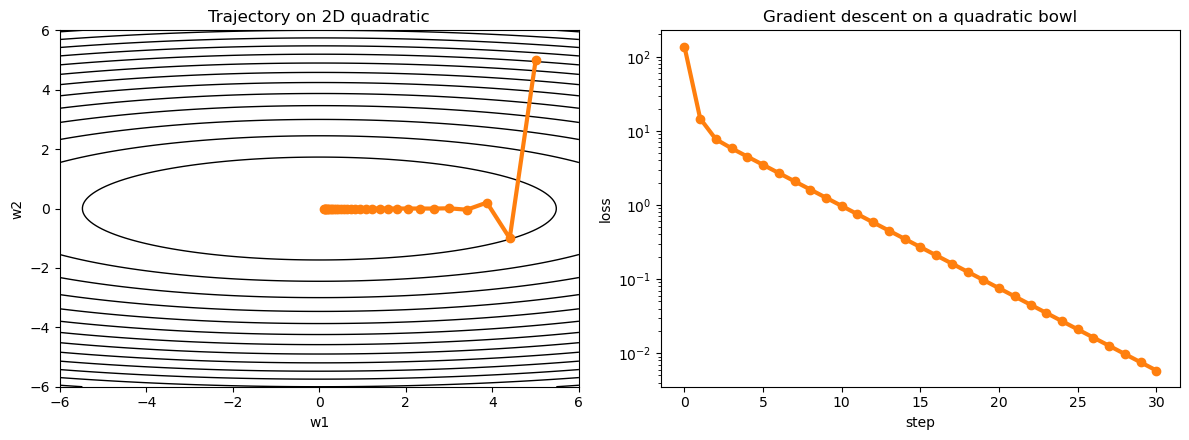

In [27]:
x = np.linspace(-6, 6, 200)
y = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x, y)
Z = 0.5 * (A[0,0]*X**2 + A[1,1]*Y**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

# Left panel: trajectory on contour plot
axs[0].contour(X, Y, Z, levels=15,colors='k',linewidths=1)
axs[0].plot(ws[:, 0], ws[:, 1],c='C1', lw=3, marker='o', ms=6)
axs[0].set_xlabel('w1')
axs[0].set_ylabel('w2')
axs[0].set_title('Trajectory on 2D quadratic')

# Right panel: loss history
axs[1].semilogy(losses, c='C1', lw=3, marker='o', ms=6)
axs[1].set_xlabel('step')
axs[1].set_ylabel('loss')
axs[1].set_title('Gradient descent on a quadratic bowl')

plt.tight_layout()
plt.show()

## 4. Linear regression from scratch

We now move to a tiny machine-learning example.

Model:   $\quad \hat y = Xw + b$

Loss (mean squared error):   $\quad L(w,b) = \frac{1}{N}\sum_{i=1}^N (\hat y_i - y_i)^2$

We will derive and implement the gradients by hand.

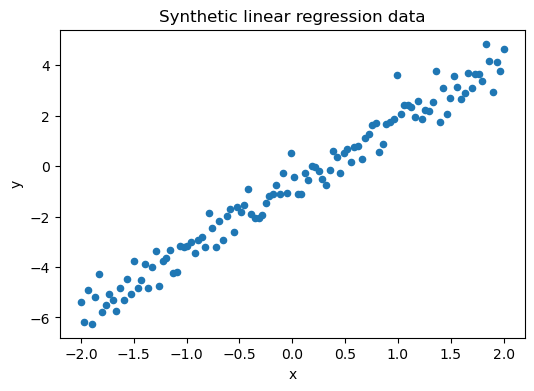

In [45]:
# Generate synthetic data
N = 120
X = np.linspace(-2, 2, N).reshape(-1, 1)
true_w = np.array([2.5])
true_b = -0.8
noise = 0.5 * np.random.randn(N)
y = X[:, 0] * true_w[0] + true_b + noise

plt.figure(figsize=(6,4))
plt.scatter(X[:,0], y, s=20)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic linear regression data')
plt.show()

In [46]:
def linear_model(X, w, b):
    return X @ w + b

def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true)**2)

def linear_regression_loss_and_grads(X, y, w, b):
    N = X.shape[0]
    y_pred = linear_model(X, w, b)
    residual = y_pred - y

    loss = np.mean(residual**2)

    # gradients
    grad_w = (2.0 / N) * X.T @ residual
    grad_b = (2.0 / N) * np.sum(residual)
    return loss, grad_w, grad_b

In [47]:
def train_linear_regression(X, y, lr=0.1, steps=200):
    d = X.shape[1]
    w = np.zeros(d)
    b = 0.0

    history = {
        "loss": [],
        "w": [],
        "b": []
    }

    for _ in range(steps):
        loss, grad_w, grad_b = linear_regression_loss_and_grads(X, y, w, b)

        w = w - lr * grad_w
        b = b - lr * grad_b

        history["loss"].append(loss)
        history["w"].append(w.copy())
        history["b"].append(b)

    return w, b, history

w_fit, b_fit, hist_lin = train_linear_regression(X, y, lr=0.1, steps=200)
w_fit, b_fit

(array([2.51779298]), np.float64(-0.7628178686730239))

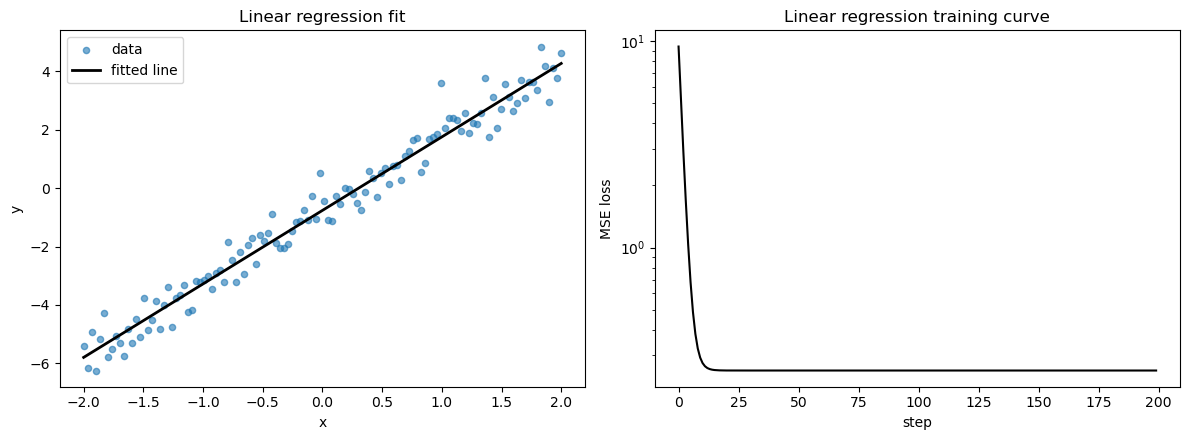

In [48]:
y_fit = linear_model(X, w_fit, b_fit)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

# Left panel: data and fitted line
axs[0].scatter(X[:, 0], y, s=20, label='data',alpha=0.6)
axs[0].plot(X[:, 0], y_fit, c='k', linewidth=2, label='fitted line')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('Linear regression fit')
axs[0].legend()

# Right panel: training curve
axs[1].semilogy(hist_lin["loss"],c='k')
axs[1].set_xlabel('step')
axs[1].set_ylabel('MSE loss')
axs[1].set_title('Linear regression training curve')

plt.tight_layout()
plt.show()

### Check
The recovered parameters should be close to the true ones:
- true slope: `2.5`
- true intercept: `-0.8`

In [49]:
print("---")
print("True w:", true_w)
print("True b:", true_b)
print("---")
print("Recovered w:", w_fit)
print("Recovered b:", b_fit)
print("Final loss:", hist_lin["loss"][-1])
print("---")

---
True w: [2.5]
True b: -0.8
---
Recovered w: [2.51779298]
Recovered b: -0.7628178686730239
Final loss: 0.2536263065495495
---


## 5. Logistic regression from scratch

Now we do binary classification.

Model:   $$ z = Xw + b, \quad p = \sigma(z) = \frac{1}{1+e^{-z}}$$

Loss (binary cross-entropy): $$ L = -\frac{1}{N}\sum_i \left[y_i \log p_i + (1-y_i)\log(1-p_i)\right]$$

For logistic regression, the gradient works out to 
$$\frac{\partial L}{\partial w} = \frac{1}{N} X^T (p-y), \qquad
\frac{\partial L}{\partial b} = \frac{1}{N}\sum_i (p_i-y_i).$$

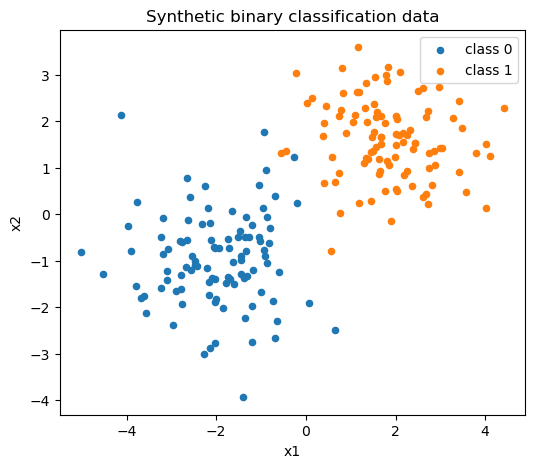

In [84]:
# Synthetic classification data: two Gaussian blobs
N0 = 100
N1 = 100

X0 = np.random.randn(N0, 2) + np.array([-2.0, -1.0])
X1 = np.random.randn(N1, 2) + np.array([ 2.0,  1.5])

X_cls = np.vstack([X0, X1])
y_cls = np.hstack([np.zeros(N0), np.ones(N1)])

plt.figure(figsize=(6,5))
plt.scatter(X0[:,0], X0[:,1], s=20, label='class 0')
plt.scatter(X1[:,0], X1[:,1], s=20, label='class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Synthetic binary classification data')
plt.legend()
plt.show()

In [85]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(p, y, eps=1e-12):
    p = np.clip(p, eps, 1.0 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def logistic_regression_loss_and_grads(X, y, w, b):
    N = X.shape[0]
    z = X @ w + b
    p = sigmoid(z)

    loss = binary_cross_entropy(p, y)

    error = p - y
    grad_w = (1.0 / N) * X.T @ error
    grad_b = (1.0 / N) * np.sum(error)
    return loss, grad_w, grad_b, p

In [86]:
def train_logistic_regression(X, y, lr=0.1, steps=300):
    d = X.shape[1]
    w = np.zeros(d)
    b = 0.0

    history = {
        "loss": [],
        "acc": [],
        "w": [],
        "b": []
    }

    for _ in range(steps):
        loss, grad_w, grad_b, p = logistic_regression_loss_and_grads(X, y, w, b)

        w = w - lr * grad_w
        b = b - lr * grad_b

        y_pred = (p >= 0.5).astype(int)
        acc = np.mean(y_pred == y)

        history["loss"].append(loss)
        history["acc"].append(acc)
        history["w"].append(w.copy())
        history["b"].append(b)

    return w, b, history

w_cls, b_cls, hist_cls = train_logistic_regression(X_cls, y_cls, lr=0.2, steps=300)
w_cls, b_cls

(array([2.47655665, 1.33067045]), np.float64(-0.29816319338774394))

In [87]:
def plot_decision_boundary(X, y, w, b, hist_cls):
    fig = plt.figure(figsize=(11, 5.5))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.6, 1], hspace=0.3, wspace=0.3)

    ax_left = fig.add_subplot(gs[:, 0])   # spans both rows
    ax_top = fig.add_subplot(gs[0, 1])
    ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_top)

    # Left panel: data + decision boundary
    ax_left.scatter(X[y == 0, 0], X[y == 0, 1], s=20, label='class 0')
    ax_left.scatter(X[y == 1, 0], X[y == 1, 1], s=20, label='class 1')

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    xx = np.linspace(x_min, x_max, 200)

    if abs(w[1]) > 1e-12:
        yy = -(w[0] * xx + b) / w[1]
        ax_left.plot(xx, yy, linewidth=2, label='decision boundary')

    ax_left.set_xlabel('x1')
    ax_left.set_ylabel('x2')
    ax_left.set_title('Logistic regression decision boundary')
    ax_left.legend()

    # Upper-right: accuracy
    ax_top.plot(hist_cls["acc"])
    ax_top.set_ylabel('accuracy')
    ax_top.set_title('Training accuracy')
    ax_top.tick_params(labelbottom=False)

    # Lower-right: loss
    ax_bottom.plot(hist_cls["loss"])
    ax_bottom.set_xlabel('step')
    ax_bottom.set_ylabel('binary cross-entropy')
    ax_bottom.set_title('Training loss')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3005270/584386079.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


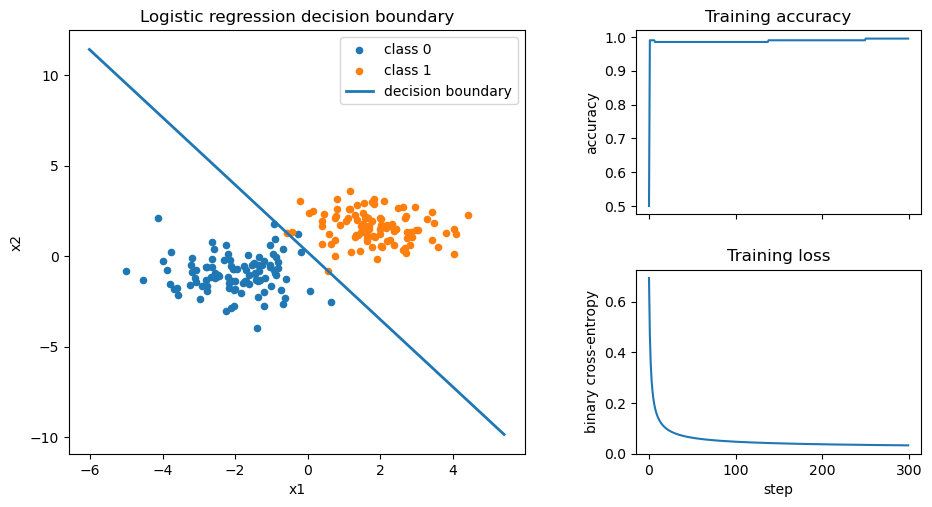

In [88]:
plot_decision_boundary(X_cls, y_cls, w_cls, b_cls, hist_cls)

In [89]:
# Final training accuracy
_, _, _, p_final = logistic_regression_loss_and_grads(X_cls, y_cls, w_cls, b_cls)
y_pred_final = (p_final >= 0.5).astype(int)
acc_final = np.mean(y_pred_final == y_cls)

print("Final accuracy:", acc_final)
print("Final weights:", w_cls)
print("Final bias:", b_cls)

Final accuracy: 0.995
Final weights: [2.47655665 1.33067045]
Final bias: -0.29816319338774394


## 6. Learning-rate experiment

A very important Week lesson is that gradient descent depends strongly on the learning rate.

Try several values and compare the training curves.

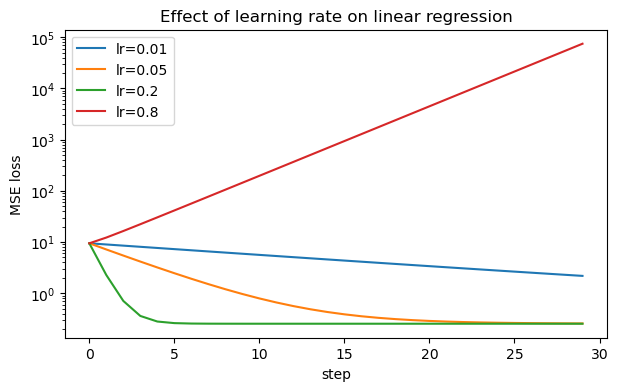

In [98]:
lrs = [0.01, 0.05, 0.2, 0.8]
plt.figure(figsize=(7,4))

for lr in lrs:
    _, _, hist = train_linear_regression(X, y, lr=lr, steps=30)
    plt.semilogy(hist["loss"], label=f"lr={lr}")

plt.xlabel('step')
plt.ylabel('MSE loss')
plt.title('Effect of learning rate on linear regression')
plt.legend()
plt.show()

## Conclusion: What to take away from Notebook 1

We now have reviewed the basic ingredients of gradient-based ML in NumPy:
- define a model
- define a loss
- compute gradients
- update parameters with gradient descent
- track training curves
- visualize the fit or classifier boundary

That is enough to support Notebook 2 topics such as:
- mini-batch gradient descent
- stochastic gradient descent
- momentum
- regularization
- a tiny neural network